# 1 — The measurement, and the model of it

*Series: **Bayesian fluorescence decays**, notebook 1 of 8. The probability
calculus is in `THEORY.md`; this notebook builds §1 and §2 of it and shows
each piece as a figure.*

**What this notebook establishes.** What the data are, what the model of them
is, and the one structural fact the whole series rests on: the expected counts
are **linear in the distance distribution**.

---

## The experiment in one paragraph

A pulsed laser fires every $T$ nanoseconds. Each detected photon is recorded
with the delay $t$ since the last pulse — its *micro time*, resolved to tens
of picoseconds. Histogramming those delays gives a **fluorescence decay**. A
donor dye alone decays with its own lifetime; put an acceptor dye a distance
$R$ away and energy transfer opens a second way for the donor to lose its
excitation, so the donor's decay gets faster and the acceptor lights up
afterwards. The rate of that transfer goes as $R^{-6}$, which is what makes a
decay a ruler.

Two more things are measured at the same time because they change the answer
if ignored: the **polarisation** of the emission, which says how much the dye
rotated while it was excited, and the light in the **other colour channel**,
because dyes leak into each other's detectors.

## The likelihood

Photons are counted independently, so the count in bin $b$ of histogram $k$ is
Poisson around the model's prediction:

$$
y_{kb} \sim \mathrm{Poisson}\big(\lambda_{kb}(\theta)\big),
\qquad
\log L(y\mid\theta) = \sum_{k,b\in M_k}\Big[y_{kb}\log\lambda_{kb} - \lambda_{kb} - \log y_{kb}!\Big].
$$

That is the whole data model. Everything else in this series is about what
$\lambda(\theta)$ is and what is known about $\theta$ before the photons
arrive.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd

S = bd.default_settings()
S['threads'] = 4
model = bd.build_model(S)
L, Ep, rel = model['L'], model['Ep'], model['rel']
print(f"fine axis: {model['n_fine']} channels of {model['dt']*1000:.0f} ps over {model['period']:.0f} ns")
print(f"rebinned:  {model['n_bin']} bins; the red pulse sits at +{model['t_pie']:.1f} ns")
print(f"distance grid: {len(rel)} points, R/R0 from {rel[0]:.2f} to {rel[-1]:.2f}")

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
fine axis: 1563 channels of 32 ps over 50 ns
rebinned:  226 bins; the red pulse sits at +25.0 ns
distance grid: 128 points, R/R0 from 0.40 to 2.23


## The time axis is deliberately uneven

A decay changes fastest immediately after a pulse and is almost flat before
the next one. Equal bins would spend most of their resolution where there is
nothing to resolve and throw away the rising edge, where the response and the
short lifetimes live. So the model works on a fine axis and reports on a
**rebinned** one: narrow bins right after each pulse, wide bins before the
next.

Rebinning is a sum, $\mathbf{R}\in\{0,1\}^{n_\mathrm{bin}\times n}$, so it
commutes with everything linear that comes before it. That is what allows the
same model to place single photons on the fine axis and fit histograms on the
coarse one.

113 bins in the green-pulse window, 113 in the red one


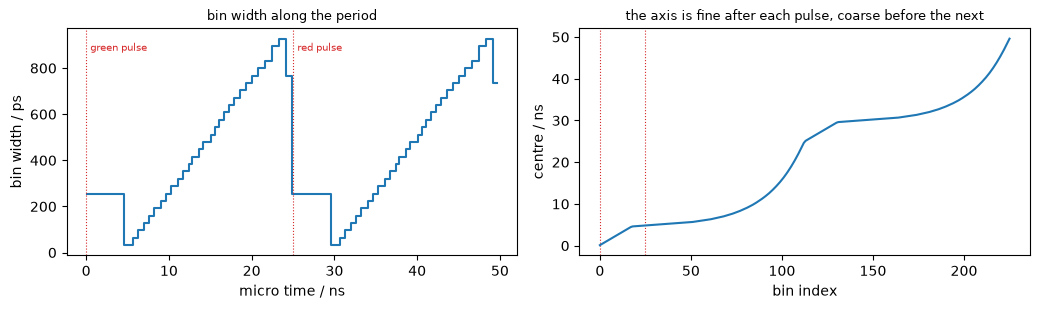

In [2]:
wid = np.asarray(Ep['wid']); tc = np.asarray(Ep['tc'])
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.2))
ax[0].step(tc, wid * 1000, where='mid', color='C0')
ax[0].set_xlabel('micro time / ns'); ax[0].set_ylabel('bin width / ps')
ax[0].set_title('bin width along the period', fontsize=9)
for x, lbl in ((0.0, 'green pulse'), (model['t_pie'], 'red pulse')):
    for a in ax:
        a.axvline(x, color='C3', lw=0.8, ls=':')
    ax[0].text(x + 0.5, ax[0].get_ylim()[1] * 0.9, lbl, fontsize=7, color='C3')
ax[1].plot(np.arange(model['n_bin']), tc, 'C0-')
ax[1].set_xlabel('bin index'); ax[1].set_ylabel('centre / ns')
ax[1].set_title('the axis is fine after each pulse, coarse before the next', fontsize=9)
fig.tight_layout()
print(f"{int(np.asarray(Ep['win_green']).sum())} bins in the green-pulse window, "
      f"{int(np.asarray(Ep['win_red']).sum())} in the red one")

## What the model is made of: a basis of decays

The expected counts of a channel are a non-negative combination of fixed
columns,

$$
\lambda_k = \mathbf{B}_{d(k)}\, a_k ,
$$

where the columns of $\mathbf{B}_d$ are

* the **instrument response** itself — scattered laser light has no lifetime;
* the **periodic** response to each lifetime on a grid,
  $\sum_{m\ge 0}(\mathrm{IRF}*e^{-\cdot/\tau_i})(t+mT)$: the sample is still
  glowing from the previous pulse when the next one arrives, so the decay does
  not start from zero;
* a **flat** column — uncorrelated background.

Every column is normalised to unit sum, so the amplitudes $a_k$ *are* counts
and the total is their sum. The response used here is analytic: a Gaussian of
width $w_d$, placed a tenth of the period into the window, skewed by an
error-function factor for the detector's transit-time tail.

33 lifetimes from 0.063 to 99.76 ns; column sums 1.0000 to 1.0000
  tau   0.13 ns: the level just BEFORE the pulse is 0.0000 of the peak -- light left over from earlier pulses
  tau   2.51 ns: the level just BEFORE the pulse is 0.0000 of the peak -- light left over from earlier pulses
  tau  62.95 ns: the level just BEFORE the pulse is 0.4611 of the peak -- light left over from earlier pulses


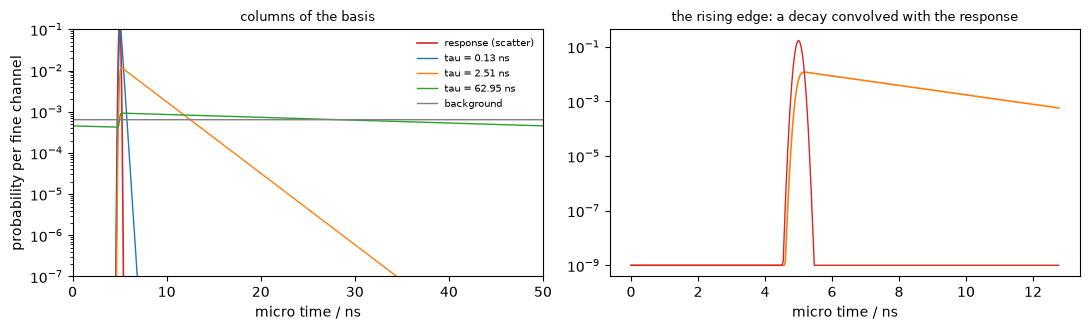

In [3]:
vals = bd.constant_values(model, S)
irf = L.analytic_irf(Ep, vals['irf_shift_gv'], vals['irf_width_gv'], vals['irf_skew_gv'])
Bf = L.basis_from_irf(Ep, irf, rebin=False).numpy()
t = np.arange(model['n_fine']) * model['dt']
taus = np.asarray(Ep['tau_c'])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogy(t, np.maximum(Bf[:, 0], 1e-9), 'C3', lw=1.2, label='response (scatter)')
for j, c in zip((3, len(taus)//2, len(taus)-3), ('C0', 'C1', 'C2')):
    ax[0].semilogy(t, np.maximum(Bf[:, 1 + j], 1e-9), c, lw=1.0, label=f'tau = {taus[j]:.2f} ns')
ax[0].semilogy(t, np.maximum(Bf[:, -1], 1e-9), '0.5', lw=1.0, label='background')
ax[0].set_ylim(1e-7, 1e-1); ax[0].set_xlim(0, model['period'])
ax[0].set_xlabel('micro time / ns'); ax[0].set_ylabel('probability per fine channel')
ax[0].legend(fontsize=7, frameon=False); ax[0].set_title('columns of the basis', fontsize=9)
ax[1].semilogy(t[:400], np.maximum(Bf[:400, 1 + len(taus)//2], 1e-9), 'C1', lw=1.2)
ax[1].semilogy(t[:400], np.maximum(Bf[:400, 0], 1e-9), 'C3', lw=1.0)
ax[1].set_xlabel('micro time / ns'); ax[1].set_title('the rising edge: a decay convolved with the response', fontsize=9)
fig.tight_layout()
print(f"{len(taus)} lifetimes from {taus[0]:.3f} to {taus[-1]:.2f} ns; "
      f"column sums {Bf.sum(0).min():.4f} to {Bf.sum(0).max():.4f}")
pre = int(0.8 * 0.10 * model['period'] / model['dt'])      # just before the pulse arrives
for j in (3, len(taus)//2, len(taus)-3):
    col = Bf[:, 1 + j]
    print(f"  tau {taus[j]:6.2f} ns: the level just BEFORE the pulse is "
          f"{col[pre]/col.max():.4f} of the peak -- light left over from earlier pulses")

## Where the distance enters

Under the **homogeneous approximation** every component of a multi-exponential
donor is quenched by the same rate,

$$
k_\mathrm{FRET}(r) = \frac{1}{\tau_0}\,r^{-6},\qquad r = R/R_0,
$$

so the transfer factor separates from the donor's own decay law and the whole
distance dependence is one number per grid point. The transfer efficiency is

$$
E(r) = \frac{1}{1+r^6},
$$

and its derivative $|\mathrm{d}E/\mathrm{d}r| = 6r^5/(1+r^6)^2$ **vanishes at
both ends**. That is not a detail of this model, it is the physics: far away,
nothing transfers however much further you go; close in, everything transfers
however much closer you get. It is the reason a distance distribution has a
window and not a range, and every figure in this series greys the outside of
it.

E within 0.01 of 0 or 1 outside R/R0 in [0.46, 2.15]  = [24, 112] A at R0 = 52 A
the same 1 % of E costs 1.50 per R/R0 at the Foerster radius and 0.135 at 1.7 -- a factor of 11


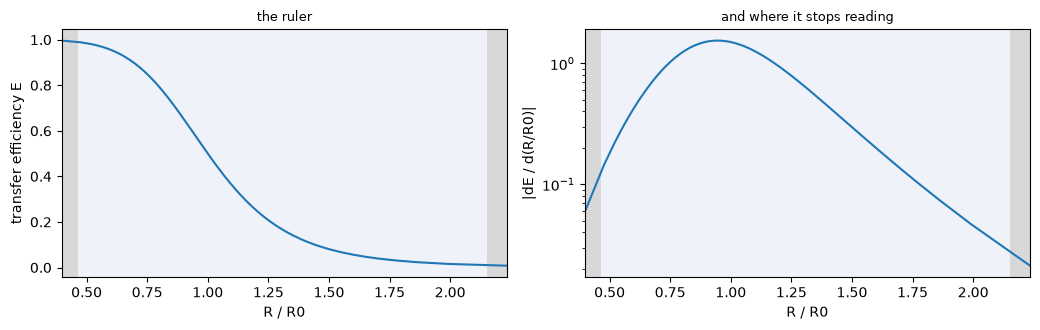

In [4]:
E = 1.0 / (1.0 + rel ** 6)
dE = 6 * rel ** 5 / (1 + rel ** 6) ** 2
lo, hi = bd.window(0.01)
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].plot(rel, E, 'C0'); ax[0].set_ylabel('transfer efficiency E')
ax[1].semilogy(rel, dE, 'C0'); ax[1].set_ylabel('|dE / d(R/R0)|')
for a in ax:
    a.set_xlabel('R / R0'); a.set_xlim(rel[0], rel[-1])
    L.shade_window(a, 0.01, label=False)
ax[0].set_title('the ruler', fontsize=9)
ax[1].set_title('and where it stops reading', fontsize=9)
fig.tight_layout()
print(f"E within 0.01 of 0 or 1 outside R/R0 in [{lo:.2f}, {hi:.2f}]  "
      f"= [{lo*S['R0']:.0f}, {hi*S['R0']:.0f}] A at R0 = {S['R0']:.0f} A")
print(f"the same 1 % of E costs {abs(np.interp(1.0, rel, dE)):.2f} per R/R0 at the Foerster radius "
      f"and {abs(np.interp(1.7, rel, dE)):.3f} at 1.7 -- a factor of {abs(np.interp(1.0,rel,dE))/abs(np.interp(1.7,rel,dE)):.0f}")

## One molecule's decay

Putting all the weight of the distance distribution on a single grid point
gives the decay of a single distance. This is worth doing explicitly because
it is what later lets the *same* forward model simulate single molecules and
fit ensembles — and because the shapes make the ruler visible: the donor's
decay shortens as the dyes come closer, and the acceptor's rises with the
donor's quenched lifetime before decaying with its own.

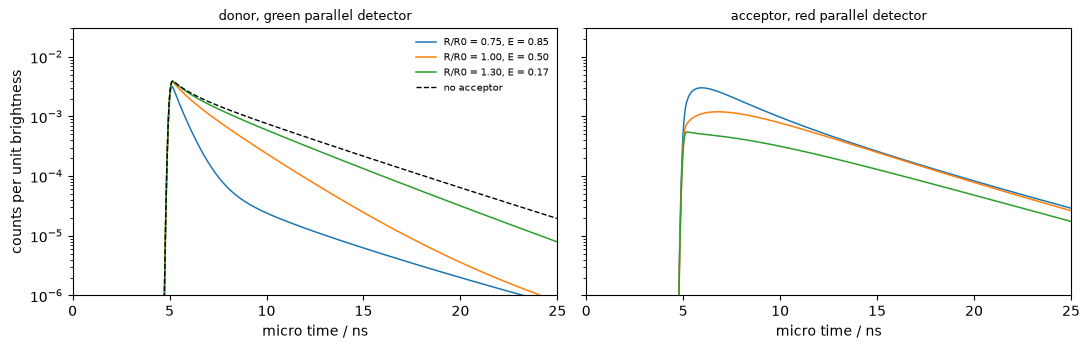

In [5]:
def one_molecule(j, keys):
    p = np.zeros(len(rel)); p[j] = 1.0
    a = L.physics_amplitudes(Ep, vals, Ep['cD'], L.tt(p), keys)
    out = {}
    for k in keys:
        d = L.parse_channel(k)[1]
        irf_k = L.analytic_irf(Ep, vals[f'irf_shift_{d}'], vals[f'irf_width_{d}'], vals[f'irf_skew_{d}'])
        out[k] = (L.basis_from_irf(Ep, irf_k, rebin=False) @ a[k]).numpy()
    return out

green = [k for k in model['keys'] if k[0] == 'DA' and k[1].startswith('gv')]
red = [k for k in model['keys'] if k[0] == 'DA' and k[1].startswith('rv')]
js = [int(np.argmin(abs(rel - c))) for c in (0.75, 1.0, 1.3)]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for j, c in zip(js, ('C0', 'C1', 'C2')):
    dec = one_molecule(j, green + red)
    ax[0].semilogy(t, np.maximum(dec[green[0]], 1e-12), c, lw=1.1, label=f'R/R0 = {rel[j]:.2f}, E = {1/(1+rel[j]**6):.2f}')
    ax[1].semilogy(t, np.maximum(dec[red[0]], 1e-12), c, lw=1.1)
d0 = [k for k in model['keys'] if k[0] == 'D0' and k[1].startswith('gv')]
v0 = dict(vals); v0['x_d0'] = L.tt(1.0)
a0 = L.physics_amplitudes(Ep, v0, Ep['cD'], L.tt(np.ones(len(rel))/len(rel)), d0)
irf0 = L.analytic_irf(Ep, vals['irf_shift_gv'], vals['irf_width_gv'], vals['irf_skew_gv'])
ax[0].semilogy(t, np.maximum((L.basis_from_irf(Ep, irf0, rebin=False) @ a0[d0[0]]).numpy(), 1e-12),
               'k--', lw=1.0, label='no acceptor')
for a, ttl in zip(ax, ('donor, green parallel detector', 'acceptor, red parallel detector')):
    a.set_xlim(0, 25); a.set_xlabel('micro time / ns'); a.set_title(ttl, fontsize=9)
ax[0].set_ylabel('counts per unit brightness'); ax[0].set_ylim(1e-6, 3e-2)
ax[0].legend(fontsize=7, frameon=False)
fig.tight_layout()

## Polarisation, and why it is in the model at all

The laser is polarised, so the dyes it excites are the ones lined up with it,
and the emission stays polarised until the molecule rotates. With fundamental
anisotropy $r_0$ and rotational correlation time $\rho$,

$$
r(t) = r_0 e^{-t/\rho},\qquad
I_\parallel \propto \tfrac{1}{3}I(t)\,[1+2r(t)],\qquad
I_\perp \propto \tfrac{1}{3}I(t)\,[1-r(t)].
$$

Real detectors need a factor $g$ for the perpendicular channel's relative
sensitivity and mixing coefficients $\ell_1,\ell_2$ for depolarisation in the
optics.

This matters for distances, not just for rotation: FRET depends on the
relative orientation of the two dyes through the orientation factor
$\kappa^2$, and a dye that does not rotate freely leaves $\kappa^2$ unknown.
Measuring the anisotropy is how one earns the right to assume it.

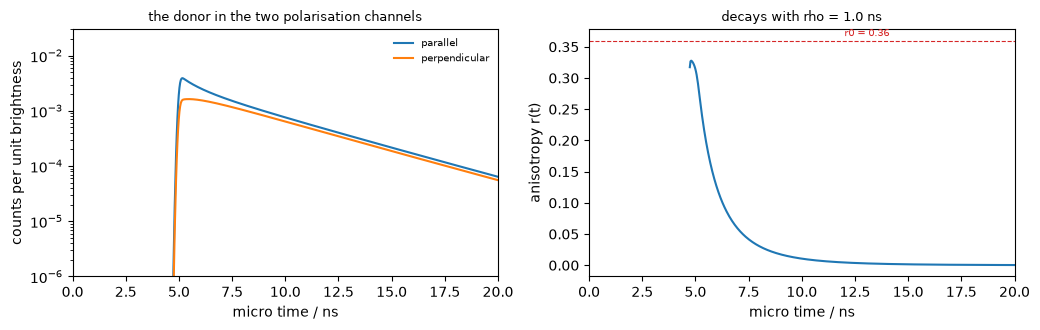

In [6]:
kv = [k for k in model['keys'] if k[0] == 'D0' and k[1].startswith('gv')][0]
kh = [k for k in model['keys'] if k[0] == 'D0' and k[1].startswith('gh')][0]
dec = {}
for k in (kv, kh):
    d = L.parse_channel(k)[1]
    irf_k = L.analytic_irf(Ep, vals[f'irf_shift_{d}'], vals[f'irf_width_{d}'], vals[f'irf_skew_{d}'])
    dec[k] = (L.basis_from_irf(Ep, irf_k, rebin=False) @ a0[k] if k in a0 else None)
a0b = L.physics_amplitudes(Ep, v0, Ep['cD'], L.tt(np.ones(len(rel))/len(rel)), [kv, kh])
cur = {}
for k in (kv, kh):
    d = L.parse_channel(k)[1]
    irf_k = L.analytic_irf(Ep, vals[f'irf_shift_{d}'], vals[f'irf_width_{d}'], vals[f'irf_skew_{d}'])
    cur[k] = (L.basis_from_irf(Ep, irf_k, rebin=False) @ a0b[k]).numpy()
g = float(vals['g'])
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].semilogy(t, np.maximum(cur[kv], 1e-12), 'C0', label='parallel')
ax[0].semilogy(t, np.maximum(cur[kh], 1e-12), 'C1', label='perpendicular')
ax[0].set_xlim(0, 20); ax[0].set_ylim(1e-6, 3e-2); ax[0].legend(fontsize=7, frameon=False)
ax[0].set_xlabel('micro time / ns'); ax[0].set_ylabel('counts per unit brightness')
ax[0].set_title('the donor in the two polarisation channels', fontsize=9)
num = cur[kv] - g * cur[kh]; den = cur[kv] + 2 * g * cur[kh]
m = den > den.max() * 1e-4
ax[1].plot(t[m], (num[m] / den[m]), 'C0')
ax[1].axhline(float(vals['r0_d']), color='C3', lw=0.8, ls='--')
ax[1].text(12, float(vals['r0_d']) * 1.02, f"r0 = {float(vals['r0_d']):.2f}", color='C3', fontsize=7)
ax[1].set_xlim(0, 20); ax[1].set_xlabel('micro time / ns'); ax[1].set_ylabel('anisotropy r(t)')
ax[1].set_title(f"decays with rho = {S['rho_donor']:.1f} ns", fontsize=9)
fig.tight_layout()

## Two lasers: what "which pulse" adds to "which sample"

A second laser, fired half a period after the first, excites the acceptor and
nothing else. This is **pulsed interleaved excitation**, and it answers a
question intensity alone cannot: a molecule showing no acceptor light either
transfers nothing, or has no working acceptor at all. Under the red pulse the
second kind stays dark.

Once there are two pulses, "which sample" and "which pulse" are different
questions and the *pair* decides the physics. Six combinations exist, and the
model calls them **scopes**:

| scope | sample | pulse | what it holds |
|---|---|---|---|
| D0 | donor only | green | the unquenched donor |
| DR | donor only | red | the donor excited by the red laser (tiny) |
| DA | labelled | green | donor, sensitised acceptor, acceptor excited directly |
| DAr | labelled | red | the acceptors of the molecules that have one |
| AG | acceptor only | green | the acceptor excited by the green laser |
| A0 | acceptor only | red | the acceptor under its own laser |

The two windows of one sample share that sample's concentration and
acquisition time, so **their ratio measures an excitation crosstalk**. That is
what makes direct excitation identifiable rather than a prior, and notebook 6
measures what it buys.

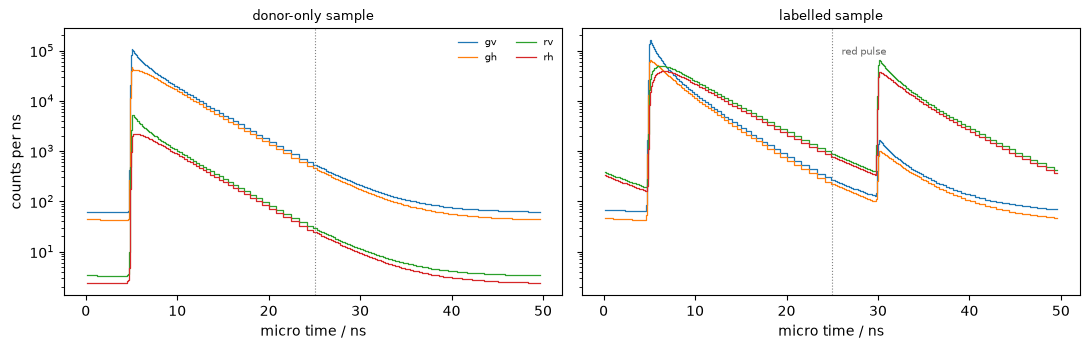

In [7]:
keys = model['keys']
kind = {'gv': 'vv', 'gh': 'vh', 'rv': 'vv', 'rh': 'vh'}
p_mix = bd.gaussian_truth(model, [0.85, 1.15], [0.5, 0.5], 0.06)
lam, _, _ = bd.expected_counts(model, S, p_mix, 0.2, {'D0': 3e5, 'DA': 3e5, 'A0': 1.8e5})
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for i, (samp, ttl) in enumerate((('D0', 'donor-only sample'), ('DA', 'labelled sample'))):
    for d, c in zip(('gv', 'gh', 'rv', 'rh'), ('C0', 'C1', 'C2', 'C3')):
        k = (samp, f'{d}_{kind[d]}')
        if samp == 'DA':
            kp = ('A0', f"{L.PIE_PARTNER[d]}_{kind[d]}")
            v = np.asarray(lam[k]) + np.asarray(lam[kp])
        else:
            v = np.asarray(lam[k])
        ax[i].step(tc, v / wid, where='mid', color=c, lw=0.9, label=d)
    ax[i].set_yscale('log'); ax[i].set_xlabel('micro time / ns'); ax[i].set_title(ttl, fontsize=9)
    ax[i].axvline(model['t_pie'], color='0.5', lw=0.8, ls=':')
ax[0].set_ylabel('counts per ns'); ax[0].legend(fontsize=7, frameon=False, ncol=2)
ax[1].text(model['t_pie'] + 1, ax[1].get_ylim()[1] * 0.3, 'red pulse', fontsize=7, color='0.4')
fig.tight_layout()

## The fact everything else rests on

The expected counts are **linear in the distance distribution**. With
$u_j = (1-x_{D0})p_j$ the number of molecules at grid distance $r_j$,

$$
\alpha^{\mathrm{don}} = Q_D\Big(x_{D0}\,\mathbf{base} + \sum_j u_j \mathbf{S}^R_j\Big)\mathbf{c}_D,
\qquad
\alpha^{\mathrm{acc}} = Q_A\Big(\sum_{j,l} u_j w^A_l \mathbf{S}^{Ag}_{jl}\mathbf{c}_D + \varepsilon_{AG}\big(\textstyle\sum_j u_j\big)\mathbf{a}^{\mathrm{dir}}\Big),
$$

every term first order in $u$. Three consequences run through the whole
series:

1. the derivative with respect to the distance distribution is a **matrix**,
   not one forward evaluation per coordinate — which is what makes an
   analytic Jacobian, and therefore a Newton method, affordable;
2. starting values come from a **non-negative least squares** problem, since
   given everything else the counts are linear in the molecule numbers;
3. all the weight on one grid point is **one molecule**, so simulating single
   molecules and fitting ensembles use the same code.

The check below could fail: it evaluates the model at a mixture and compares
it against the mixture of the model at each grid point.

In [8]:
ks = [k for k in keys if k[0] == 'DA']
a_mix = L.physics_amplitudes(Ep, vals, Ep['cD'], L.tt(p_mix), ks)
acc = {k: np.zeros_like(np.asarray(a_mix[k])) for k in ks}
for j in np.nonzero(p_mix > 1e-12)[0]:
    e = np.zeros(len(rel)); e[j] = 1.0
    a_j = L.physics_amplitudes(Ep, vals, Ep['cD'], L.tt(e), ks)
    for k in ks:
        acc[k] += p_mix[j] * np.asarray(a_j[k])
err = max(float(np.abs(acc[k] - np.asarray(a_mix[k])).max() / max(np.abs(np.asarray(a_mix[k])).max(), 1e-300)) for k in ks)
print(f'model at the mixture vs mixture of the model at each grid point:')
print(f'  largest relative difference over {len(ks)} channels: {err:.2e}')
print(f'  (the donor-only term is the same in both and cancels; what is compared is the FRET part)')
assert err < 1e-10, 'the amplitudes are not linear in p(R) -- everything downstream would be wrong'
print('  linear to machine precision.')

model at the mixture vs mixture of the model at each grid point:
  largest relative difference over 4 channels: 1.60e-12
  (the donor-only term is the same in both and cancels; what is compared is the FRET part)
  linear to machine precision.


## What comes next

The model is now a map from parameters to expected counts, and the counts are
Poisson around it. The obvious next step — invert it — is where the trouble
starts, and it is notebook 2.

**Established here.** The likelihood (THEORY §1.1); the uneven time axis
(§1.2); the basis with its periodic columns (§2.2); the ruler $E(r)$ and the
window where it stops reading (§2.3, §7.3); polarisation (§2.5); the six PIE
scopes (§2.7); and linearity in $p(R)$ (§2.4), checked to machine precision.